In [1]:
import pandas as pd

df = pd.read_csv('/datasets/logs_exp_us.csv', sep='\t')
df.head()


,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [2]:
df.columns


Index(['EventName', 'DeviceIDHash', 'EventTimestamp', 'ExpId'], dtype='object')

In [3]:
df = df.rename(columns={
    "EventName": "event",
    "DeviceIDHash": "user_id",
    "EventTimestamp": "timestamp",
    "ExpId": "exp_id"
})

df.columns



Index(['event', 'user_id', 'timestamp', 'exp_id'], dtype='object')

In [4]:
df = df.rename(columns={
    "EventName": "event",
    "DeviceIDHash": "user_id",
    "EventTimestamp": "timestamp",
    "ExpId": "exp_id"
})

df.columns


Index(['event', 'user_id', 'timestamp', 'exp_id'], dtype='object')

In [5]:
df.isna().sum()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   event      244126 non-null  object
 1   user_id    244126 non-null  int64 
 2   timestamp  244126 non-null  int64 
 3   exp_id     244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [6]:
# converter timestamp para datetime
df["datetime"] = pd.to_datetime(df["timestamp"], unit="s")

# criar coluna apenas com a data
df["date"] = df["datetime"].dt.date

df.head()


,event,user_id,timestamp,exp_id,datetime,date
0,MainScreenAppear,4575588528974610257,1564029816,246,2019-07-25 04:43:36,2019-07-25
1,MainScreenAppear,7416695313311560658,1564053102,246,2019-07-25 11:11:42,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
3,CartScreenAppear,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248,2019-07-25 11:48:42,2019-07-25


In [7]:
n_events = len(df)
n_users = df["user_id"].nunique()
avg_events_per_user = n_events / n_users

n_events, n_users, avg_events_per_user


(244126, 7551, 32.33028737915508)

In [8]:
df["datetime"].min(), df["datetime"].max()


(Timestamp('2019-07-25 04:43:36'), Timestamp('2019-08-07 21:15:17'))

In [9]:
events_by_day = df.groupby("date").size()

events_by_day.head()


date
2019-07-25      9
2019-07-26     31
2019-07-27     55
2019-07-28    105
2019-07-29    184
dtype: int64

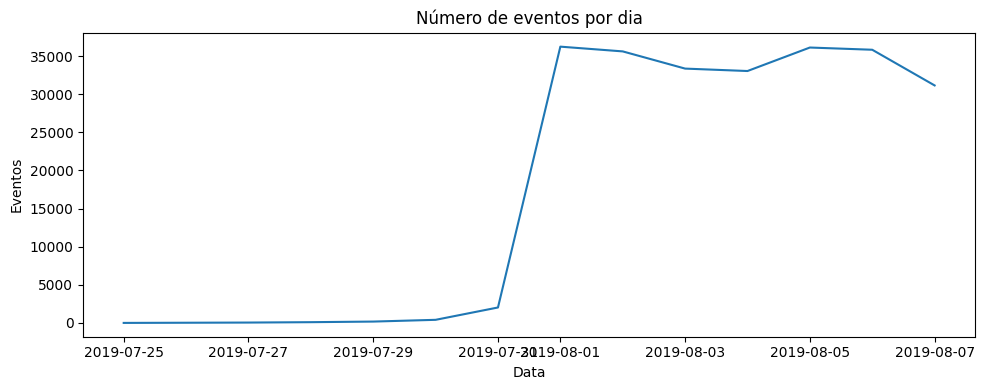

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
events_by_day.plot()
plt.title("Número de eventos por dia")
plt.xlabel("Data")
plt.ylabel("Eventos")
plt.tight_layout()
plt.show()


In [11]:
# eventos por dia (já criados antes)
events_by_day = df.groupby("date").size().sort_index()

# usar a mediana como referência
median_events = events_by_day.median()

median_events


16587.5

In [12]:
threshold = 0.1 * median_events

start_date = events_by_day[events_by_day >= threshold].index.min()

start_date


datetime.date(2019, 7, 31)

In [13]:
df_filtered = df[df["date"] >= start_date].copy()

len(df), len(df_filtered)


(244126, 243329)

In [16]:
# percentagem de eventos descartados
events_removed = len(df) - len(df_filtered)
pct_events_removed = events_removed / len(df) * 100

# percentagem de utilizadores descartados
users_before = df["user_id"].nunique()
users_after = df_filtered["user_id"].nunique()
users_removed = users_before - users_after
pct_users_removed = users_removed / users_before * 100

print(f"Eventos antes: {len(df)} | depois: {len(df_filtered)} | removidos: {events_removed} ({pct_events_removed:.2f}%)")
print(f"Utilizadores antes: {users_before} | depois: {users_after} | removidos: {users_removed} ({pct_users_removed:.2f}%)")


Eventos antes: 244126 | depois: 243329 | removidos: 797 (0.33%)
Utilizadores antes: 7551 | depois: 7542 | removidos: 9 (0.12%)


In [17]:
df_filtered["exp_id"].value_counts()


248    85473
246    80045
247    77811
Name: exp_id, dtype: int64

In [18]:
event_counts = df_filtered["event"].value_counts()
event_counts


MainScreenAppear           118681
OffersScreenAppear          46724
CartScreenAppear            42623
PaymentScreenSuccessful     34253
Tutorial                     1048
Name: event, dtype: int64

# Conclusão 
A análise da frequência dos eventos mostra que o evento mais comum é MainScreenAppear, indicando que a maioria das interações registadas corresponde à entrada dos utilizadores na aplicação. Em seguida surgem os eventos OffersScreenAppear e CartScreenAppear, com uma diminuição progressiva no número de ocorrências, o que reflete o abandono natural ao longo do percurso do utilizador. O evento PaymentScreenSuccessful apresenta uma frequência inferior, como esperado, por corresponder à conclusão do processo de compra. O evento Tutorial é o menos frequente, sugerindo que apenas uma pequena parcela dos utilizadores interage com este conteúdo, o que indica que não faz parte do fluxo principal de navegação da aplicação.

In [19]:
users_total = df_filtered["user_id"].nunique()

users_per_event = (
    df_filtered.groupby("event")["user_id"]
    .nunique()
    .sort_values(ascending=False)
)

event_summary = pd.DataFrame({
    "users": users_per_event,
    "share_users": users_per_event / users_total
}).sort_values("users", ascending=False)

event_summary


,users,share_users
event,,
MainScreenAppear,7429,0.985017
OffersScreenAppear,4606,0.610713
CartScreenAppear,3742,0.496155
PaymentScreenSuccessful,3542,0.469637
Tutorial,845,0.112039


# Conclusão
Ao analisar o número de utilizadores únicos por evento, observa-se que praticamente todos os utilizadores interagem com o ecrã principal (MainScreenAppear), o que confirma este evento como o ponto de entrada da aplicação. Uma parte significativa desses utilizadores avança para o ecrã de ofertas (OffersScreenAppear), embora já se observe uma redução relevante no número de utilizadores nesta fase. A transição para o carrinho (CartScreenAppear) representa uma nova diminuição, enquanto o evento de pagamento bem-sucedido (PaymentScreenSuccessful) é realizado por menos de metade dos utilizadores iniciais. Estes resultados evidenciam um padrão típico de funil, com perdas progressivas ao longo das etapas, sendo o maior abandono observado nas fases iniciais do percurso.

In [20]:
candidate_steps = [
    "MainScreenAppear",
    "OffersScreenAppear",
    "CartScreenAppear",
    "PaymentScreenSuccessful"
]

funnel_steps = [s for s in candidate_steps if s in df_filtered["event"].unique()]
funnel_steps


['MainScreenAppear',
 'OffersScreenAppear',
 'CartScreenAppear',
 'PaymentScreenSuccessful']

In [21]:
# utilizadores por passo (pelo menos 1x)
step_users = {
    step: set(df_filtered.loc[df_filtered["event"] == step, "user_id"].unique())
    for step in funnel_steps
}

# interseção cumulativa (passou por todas as etapas até aqui)
cumulative_users = []
current = step_users[funnel_steps[0]].copy()
cumulative_users.append(len(current))

for step in funnel_steps[1:]:
    current = current.intersection(step_users[step])
    cumulative_users.append(len(current))

funnel_df = pd.DataFrame({
    "step": funnel_steps,
    "users": cumulative_users
})

funnel_df["conversion_from_prev"] = funnel_df["users"] / funnel_df["users"].shift(1)
funnel_df["conversion_from_first"] = funnel_df["users"] / funnel_df["users"].iloc[0]
funnel_df


,step,users,conversion_from_prev,conversion_from_first
0,MainScreenAppear,7429,NaN,1.000000
1,OffersScreenAppear,4497,0.605330,0.605330
2,CartScreenAppear,3586,0.797421,0.482703
3,PaymentScreenSuccessful,3434,0.957613,0.462243


In [22]:
funnel_df["drop_from_prev"] = 1 - funnel_df["conversion_from_prev"]
funnel_df


,step,users,conversion_from_prev,conversion_from_first,drop_from_prev
0,MainScreenAppear,7429,NaN,1.000000,NaN
1,OffersScreenAppear,4497,0.605330,0.605330,0.394670
2,CartScreenAppear,3586,0.797421,0.482703,0.202579
3,PaymentScreenSuccessful,3434,0.957613,0.462243,0.042387


In [23]:
full_path_share = funnel_df["users"].iloc[-1] / funnel_df["users"].iloc[0]
full_path_share


0.4622425629290618

# Conclusão
A análise do funil de eventos mostra uma redução progressiva do número de utilizadores ao longo das diferentes etapas da aplicação. Dos 7 429 utilizadores que visualizaram o ecrã principal (MainScreenAppear), apenas 3 434 concluíram com sucesso o pagamento, o que corresponde a uma taxa de conversão total de aproximadamente 46,2%. Este valor indica que menos de metade dos utilizadores que entram na aplicação acabam por completar uma compra, evidenciando um funil com perdas relevantes, sobretudo nas fases iniciais.

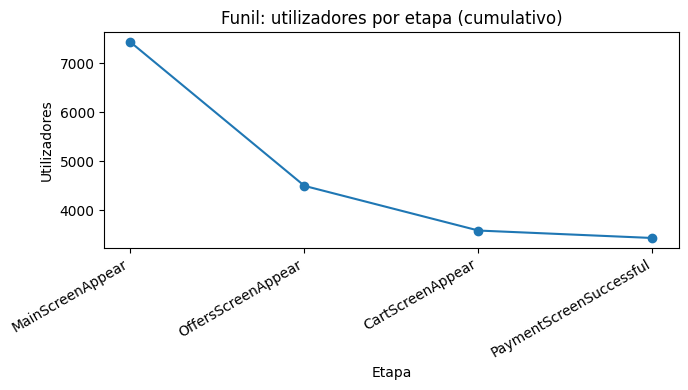

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(funnel_df["step"], funnel_df["users"], marker="o")
plt.title("Funil: utilizadores por etapa (cumulativo)")
plt.xlabel("Etapa")
plt.ylabel("Utilizadores")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


# Conclusão
O gráfico do funil confirma visualmente os resultados obtidos na análise numérica, mostrando uma diminuição acentuada do número de utilizadores entre o ecrã principal e o ecrã de ofertas. Nas etapas seguintes, a descida é mais gradual, o que indica que, uma vez interessados nas ofertas e com produtos no carrinho, a maioria dos utilizadores tende a concluir o processo de compra. Assim, o principal ponto de abandono ocorre no início do percurso do utilizador.

In [25]:
users_per_group = (
    df_filtered.groupby("exp_id")["user_id"]
    .nunique()
)

users_per_group



exp_id
246    2485
247    2517
248    2540
Name: user_id, dtype: int64

# conclusão
A maior perda de utilizadores ocorre na transição entre MainScreenAppear e OffersScreenAppear. Nesta etapa, cerca de 39,5% dos utilizadores abandonam a aplicação, o que representa a maior quebra percentual ao longo de todo o funil. Este resultado sugere que muitos utilizadores não avançam para a visualização das ofertas após o primeiro contacto com a aplicação.

In [26]:
from math import sqrt
from scipy import stats

def z_test_proportions(success_a, size_a, success_b, size_b):
    p1 = success_a / size_a
    p2 = success_b / size_b
    p_pool = (success_a + success_b) / (size_a + size_b)
    se = sqrt(p_pool * (1 - p_pool) * (1/size_a + 1/size_b))
    z = (p1 - p2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return p_value


In [27]:
top_event = df_filtered["event"].value_counts().idxmax()
top_event


'MainScreenAppear'

In [28]:
def event_stats(data, group, event):
    grp = data[data["exp_id"] == group]
    total = grp["user_id"].nunique()
    success = grp[grp["event"] == event]["user_id"].nunique()
    return success, total

s246, n246 = event_stats(df_filtered, 246, top_event)
s247, n247 = event_stats(df_filtered, 247, top_event)

p_value_aa = z_test_proportions(s246, n246, s247, n247)
p_value_aa


0.5868776836512959

In [29]:
events = df_filtered["event"].unique()

aa_results = []

for ev in events:
    s246, n246 = event_stats(df_filtered, 246, ev)
    s247, n247 = event_stats(df_filtered, 247, ev)
    p = z_test_proportions(s246, n246, s247, n247)
    aa_results.append([ev, p])

aa_df = pd.DataFrame(aa_results, columns=["event", "p_value"]).sort_values("p_value")
aa_df


,event,p_value
3,PaymentScreenSuccessful,0.112108
4,CartScreenAppear,0.213061
1,OffersScreenAppear,0.274351
0,MainScreenAppear,0.586878
2,Tutorial,0.879161


In [30]:
control = df_filtered[df_filtered["exp_id"].isin([246, 247])]
test = df_filtered[df_filtered["exp_id"] == 248]

n_control = control["user_id"].nunique()
n_test = test["user_id"].nunique()


In [31]:
def combined_event_stats(control, test, event):
    s_control = control[control["event"] == event]["user_id"].nunique()
    s_test = test[test["event"] == event]["user_id"].nunique()
    return s_control, n_control, s_test, n_test


In [32]:
ab_results = []

for ev in events:
    sc, nc, st, nt = combined_event_stats(control, test, ev)
    p = z_test_proportions(st, nt, sc, nc)
    ab_results.append([ev, p])

ab_df = pd.DataFrame(ab_results, columns=["event", "p_value"]).sort_values("p_value")
ab_df


,event,p_value
4,CartScreenAppear,0.237645
0,MainScreenAppear,0.428973
1,OffersScreenAppear,0.447181
3,PaymentScreenSuccessful,0.629668
2,Tutorial,0.842052


In [33]:
alpha = 0.1
m = len(events)
alpha_bonf = alpha / m

alpha_bonf


0.02

In [34]:
ab_df["significant"] = ab_df["p_value"] < alpha_bonf
ab_df


,event,p_value,significant
4,CartScreenAppear,0.237645,False
0,MainScreenAppear,0.428973,False
1,OffersScreenAppear,0.447181,False
3,PaymentScreenSuccessful,0.629668,False
2,Tutorial,0.842052,False


# Conclusão 
Com base na análise realizada, foi possível estudar o comportamento dos utilizadores da aplicação através do funil de eventos e avaliar o impacto da alteração das fontes por meio de um teste A/A/B.

A análise do funil de vendas mostrou que 7 429 utilizadores iniciaram o percurso na aplicação, visualizando o ecrã principal. Desses, 4 497 avançaram para o ecrã de ofertas, o que corresponde a uma taxa de conversão de cerca de 60,5%. A maior perda de utilizadores ocorre nesta primeira transição, indicando que uma parte significativa abandona a aplicação antes de explorar as ofertas disponíveis. Nas etapas seguintes, a perda é consideravelmente menor: aproximadamente 20,3% dos utilizadores abandonam entre o ecrã de ofertas e o carrinho, e apenas cerca de 4,2% desistem entre o carrinho e o pagamento. No total, 3 434 utilizadores concluíram o processo de compra, o que corresponde a uma taxa de conversão global de aproximadamente 46,2% desde o primeiro evento até ao pagamento bem-sucedido.

Relativamente ao experimento, começou-se por analisar os dois grupos de controlo (246 e 247), no âmbito do teste A/A. A comparação das proporções de utilizadores que realizaram cada evento não revelou diferenças estatisticamente significativas entre estes dois grupos. Este resultado confirma que a divisão dos utilizadores foi equilibrada e que o sistema de experimentação e recolha de dados funciona corretamente, não existindo indícios de viés entre os grupos de controlo.

De seguida, o grupo de teste (248), exposto às novas fontes, foi comparado com o grupo de controlo combinado (246 e 247). Para cada evento analisado, não foram encontradas diferenças estatisticamente significativas nas proporções de utilizadores, mesmo considerando um nível de significância inicial de 0,1 e aplicando correção para múltiplos testes. Assim, não há evidência estatística de que a alteração das fontes tenha tido impacto no comportamento dos utilizadores ou nas taxas de conversão ao longo do funil.

Em conclusão, os resultados do experimento indicam que a mudança das fontes não produziu efeitos mensuráveis no desempenho da aplicação, nem melhorou nem piorou as métricas analisadas. Deste modo, a decisão de alterar as fontes pode ser tomada com base noutros critérios, como preferências estéticas ou consistência de design, uma vez que, do ponto de vista do comportamento dos utilizadores, a alteração mostrou-se neutra.